In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("spam.csv",encoding="latin-1")

In [41]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [42]:
df.sample(3)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4854,ham,Same to u...,NaN,NaN,NaN
1178,ham,"I'm outside islands, head towards hard rock an...",NaN,NaN,NaN
100,ham,Okay name ur price as long as its legal! Wen c...,NaN,NaN,NaN


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [44]:
df.isnull().sum()


,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


#Column delete
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace=True)

In [45]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [46]:
df["v1"].value_counts()

,count
v1,
ham,4825
spam,747


In [47]:
df[df["v1"]=="spam"]["v2"]

,v2
2,Free entry in 2 a wkly comp to win FA Cup fina...
5,FreeMsg Hey there darling it's been 3 week's n...
8,WINNER!! As a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...
11,"SIX chances to win CASH! From 100 to 20,000 po..."
...,...
5537,Want explicit SEX in 30 secs? Ring 02073162414...
5540,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,Had your contract mobile 11 Mnths? Latest Moto...
5566,REMINDER FROM O2: To get 2.50 pounds free call...


In [48]:
df[df["v1"]=="ham"]["v2"]

,v2
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."
6,Even my brother is not like to speak with me. ...
...,...
5565,Huh y lei...
5568,Will Ì_ b going to esplanade fr home?
5569,"Pity, * was in mood for that. So...any other s..."
5570,The guy did some bitching but I acted like i'd...


In [49]:
df[df["v1"]=="ham"]["v2"][5570]

"The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free"

In [50]:
df.rename(columns={"v1":"Target","v2":"Text"},inplace=True)

In [51]:
df

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


<Axes: xlabel='Target'>

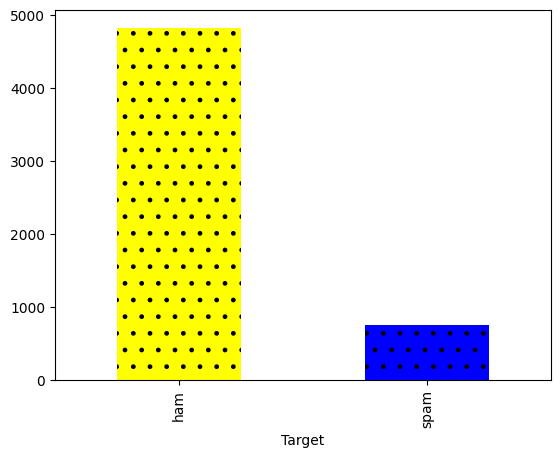

In [52]:
df["Target"].value_counts().plot( kind="bar", color=["yellow","blue"],hatch=".")

In [53]:
df.duplicated().sum()

np.int64(403)

In [54]:
df.drop_duplicates(keep="first",inplace=True)

In [55]:
df.duplicated().sum()


np.int64(0)

In [56]:
df

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [57]:
df.shape


(5169, 5)

In [58]:
! pip install nltk

In [59]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [60]:
df["num_chars"]= df["Text"].apply(len)

In [61]:
df.sample(3)

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_chars
4898,ham,"Haha, that was the first person I was gonna ask",NaN,NaN,NaN,47
707,ham,Quite late lar... Ard 12 anyway i wun b drivin...,NaN,NaN,NaN,49
2538,ham,The monthly amount is not that terrible and yo...,NaN,NaN,NaN,106


In [62]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [63]:
df["num_words"] =df["Text"].apply(len)

In [64]:
df.sample(3)

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_chars,num_words
715,ham,When i have stuff to sell i.ll tell you,NaN,NaN,NaN,39,39
2889,ham,Shuhui has bought ron's present it's a swatch ...,NaN,NaN,NaN,54,54
572,ham,Can you open the door?,NaN,NaN,NaN,22,22


In [65]:
df["num_words"] =df["Text"].apply(lambda x: len(nltk.word_tokenize(x)))

In [66]:
df

,Target,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4,num_chars,num_words
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN,111,24
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN,155,37
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN,61,15
...,...,...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN,161,35
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN,37,9
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN,57,15
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN,125,27
